In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from concurrent.futures import ProcessPoolExecutor
from sklearn.metrics import f1_score, matthews_corrcoef

test_data = False
#sensor = 'Siegelbach'
sensor = 'Okriftel'

/home/dverbrug/miniconda3/envs/SyncSense/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Load Data

In [2]:
data_path =  '../Dataset/EWSN_disjunct/'

sample_time = 1/12e6

In [3]:
detections_file = data_path + sensor + "_Testing_detections.pkl.gz"
detections = pd.read_pickle(detections_file, compression='gzip')
detections.head()

,timestamp,timing_base,timing_sync_source,duplicate_count,low_confidence_count,corrected_bits_count,level_noise,level_signal,type,aircraft_address,payload,sample_pos,sample_size,sample_rate,sample_format,sample_data_offset,uf,duration,startIdx,endIdx
0,478438758419160,2,1,0,0,0,-103.56009,-84.65337,ul-s,400804,000007ff2fa0000000,0,0,0,0,0,0,19750,229075,229312
1,478438760085744,2,1,0,0,0,-103.56009,-82.98988,ul-s,345614,0040010cbf0000000,0,0,0,0,0,0,19750,249075,249312
2,478438761057410,2,1,0,0,0,-95.34322,-91.87067,ul-s,4cabc7,00400406180000000,0,0,0,0,0,0,19750,260734,260971
3,478438761236660,2,1,0,0,0,-91.94641,-79.06405,ul-s,39e68c,000002eba9b0000000,0,0,0,0,0,0,19750,262885,263122
4,478438761890160,2,1,0,0,0,-95.85307,-80.49016,ul-s,406c71,000007fb55f0000000,0,0,0,0,0,0,19750,270727,270964


,timestamp,timing_base,timing_sync_source,duplicate_count,low_confidence_count,corrected_bits_count,level_noise,level_signal,type,aircraft_address,payload,sample_pos,sample_size,sample_rate,sample_format,sample_data_offset,uf,duration,startIdx,endIdx
0,385080087172823,2,1,0,0,0,-91.60279,-65.85722,ul-s,3dd2a6,000002962860000000,0,0,0,0,0,0,19750,43553,43790
1,385080089496657,2,1,0,0,0,-105.34322,-88.22320,ul-s,ae2210,00400fc9670000000,0,0,0,0,0,0,19750,71439,71676
2,385080090585573,2,1,0,0,0,-91.37720,-71.13927,ul-s,4bb87a,0000072d2e90000000,0,0,0,0,0,0,19750,84506,84743
3,385080090868240,2,1,0,0,0,-103.47235,-79.84791,ul-s,3d08df,004001ea02b0000000,0,0,0,0,0,0,19750,87898,88135
4,385080090911823,2,1,0,0,0,-94.86897,-66.02766,ul-s,3dd2a6,000002962860000000,0,0,0,0,0,0,19750,88421,88658


# Data Rate Considerations

## 1. Full I/Q Data

In [6]:
# add data rate cols
detections['t'] = detections.endIdx * sample_time # seconds
detections['tbin'] = np.floor(detections['t']).astype(int)
detections['bytes'] = (detections.endIdx - detections.startIdx + 1).clip(upper=512) * 2*16 / 8 # bytes
detections.sample()
print(len(detections))

12223


In [5]:
# calculate entropy 
def calc_entropy(series):
    value_counts = series.value_counts()
    probabilities = value_counts / len(series)
    entropy = - (probabilities * np.log2(probabilities)).sum()
    return entropy
print(calc_entropy(detections['payload']))

8.863544136560087


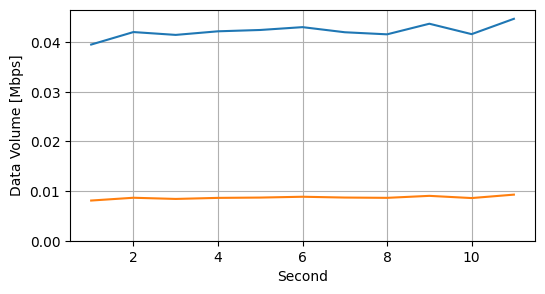

In [ ]:
rate = detections.groupby('tbin').bytes.sum()[:-1]
detec = detections['tbin'].value_counts()
entropy = detections.groupby('tbin').payload.apply(calc_entropy)[:-1]
detec = detec.sort_index()[:-1]
plt.figure(figsize=(6,3))
plt.plot(rate.index+1, rate*8/1024/1024, label='Uncompressed')
plt.plot(detec.index+1,detec*8*5/1024/1024, label = 'ML')
# plt.plot(detec.index+1,detec*entropy/1024/1024, label = 'Theoretical limit')
plt.xlabel("Second")
plt.ylabel("Data Volume [Mbps]")
plt.grid()
plt.ylim(bottom=0)
plt.show()

In [28]:
print(rate)

tbin
0     1011804.0
1     1075980.0
2     1063724.0
3     1081808.0
4     1083776.0
5     1103424.0
6     1077712.0
7     1065236.0
8     1120552.0
9     1064168.0
10    1144656.0
Name: bytes, dtype: float64


Our options are:
* Reducing resolution: Only realistic option here is down to 8 bits per sample, which would cut data volume into half
* Reducing sample rate by downsampling signals: How far can we go while still retaining good enough similarity?

## 2. Reducing Resolution to 8 Bits

Simply drop lower 8 bits of each sample.

In [22]:
correlation_file = data_path + sensor + '_correlation'

if test_data:
    correlation_file += '_eval'

xcorrs = pd.read_csv(correlation_file + '.csv.gz', index_col=[0,1], compression='gzip')
xcorrs.head()

corr  bit_diff
i    j                       
1517 2333  0.999131         0
4880 6057  0.999008         0
3235 8129  0.998905         0
     8891  0.998866         0
1517 6057  0.998643         0

In [23]:
correlation_file = data_path + sensor + '_correlation_8bit'

if test_data:
    correlation_file += '_eval'

xcorrs8bit = pd.read_csv(correlation_file + '.csv.gz', index_col=[0,1], compression='gzip')
xcorrs8bit.head()

corr  bit_diff
i     j                       
4880  6057  0.998975         0
1517  2333  0.998894         0
3235  8129  0.998838         0
      8891  0.998744         0
11879 3235  0.998739         0

In [24]:
diffs = (xcorrs8bit['corr'] - xcorrs['corr']).to_frame()
diffs.head()

corr
i j           
4 6  -0.000817
  7   0.002610
  10  0.001498
  16  0.002505
  21  0.000966

In [25]:
bins = np.arange(0, 1.1, 0.1)
diffs['bin'] = pd.cut(xcorrs['corr'], bins=bins, include_lowest=True)

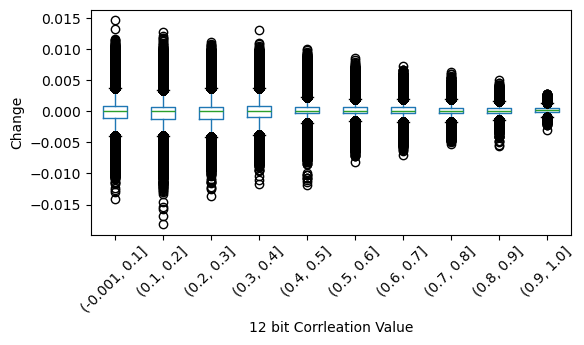

In [26]:
plt.figure(figsize=(6,3))
diffs.boxplot(ax=plt.gca(), column='corr', by='bin', grid=False)
plt.xlabel('12 bit Corrleation Value')
plt.ylabel('Change')
plt.suptitle('')
plt.title('')
plt.xticks(rotation=45)
plt.show()

In [27]:
m = xcorrs['corr'] >= 0.95
diffs.loc[m, 'corr'].describe()

count    6505.000000
mean        0.000213
std         0.000426
min        -0.001846
25%        -0.000063
50%         0.000159
75%         0.000456
max         0.002296
Name: corr, dtype: float64

## 3. Downsampling

In [ ]:
%%time

correlation_file = data_path + sensor + f'_correlation'

if test_data:
    correlation_file += '_eval'

xcorrs = pd.read_csv(correlation_file + '.csv.gz', index_col=[0,1], compression='gzip')
xcorrs.columns = [f'corr{1}', f'hamming']

for decimation_factor in [2, 4, 8, 16, 32, 64, 128]:
    correlation_file = data_path + sensor + f'_correlation_downsampled_{decimation_factor}'
    
    if test_data:
        correlation_file += '_eval'

    tmp = pd.read_csv(correlation_file + '.csv.gz', index_col=[0,1], compression='gzip')
    tmp.columns = [f'corr{decimation_factor}', f'hamming{decimation_factor}']

    xcorrs = pd.concat([xcorrs, tmp[f'corr{decimation_factor}']], axis=1)

xcorrs.head()

In [ ]:
plt.figure(figsize=(6, 3))

corr_columns = [col for col in xcorrs.columns if col.startswith('corr')]

for column in corr_columns:
    x = np.sort(xcorrs[column])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=column)

plt.xlabel('Correlation Value')
plt.ylabel('ECDF')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(6, 3))

corr_columns = [col for col in xcorrs.columns if col.startswith('corr')]

for column in corr_columns:
    plt.hist(xcorrs[column], bins=50, alpha=0.5, label=column, density=True)

plt.xlabel('Correlation Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
corr_columns = [col for col in xcorrs.columns if col.startswith('corr')]
diffs = xcorrs[corr_columns].drop(columns=['corr1']).subtract(xcorrs['corr1'], axis=0)

plt.figure(figsize=(6, 3))

for column in diffs.columns:
    x = np.sort(diffs[column])
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=column)

plt.xlabel('Difference to Original Correlation')
plt.ylabel('ECDF')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
np.sum(xcorrs.hamming == 0), np.sum(xcorrs.hamming > 0)

In [ ]:
xcorrs.head()

So if we say all signals with a similarity of .95 or higher are the same and all the others are not. Let's look at accuracy, precision and recall:
- Accuracy = correctly matched and not matched / total numbers of pairs
- True positive rate (recall) = correctly matched / all matched
- False positive rate = incorrectly matched / all non-matches
- Precision = correctly matched / all matched

In [ ]:
thresholds = np.round(np.linspace(0.85, 0.99, 7), 2)
factors = [1, 2, 4, 8, 16, 32, 64]

metrics = []

ground_truth = xcorrs['hamming'] == 0

for threshold in thresholds:
    for factor in factors:
        predictions = xcorrs[f'corr{factor}'] >= threshold
    
        # Confusion matrix components
        true_positive = ((ground_truth == True) & (predictions == True)).sum()
        true_negative = ((ground_truth == False) & (predictions == False)).sum()
        false_positive = ((ground_truth == False) & (predictions == True)).sum()
        false_negative = ((ground_truth == True) & (predictions == False)).sum()
    
        # Metrics
        accuracy = (true_positive + true_negative) / len(xcorrs)
        recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
        false_positive_rate = false_positive / (false_positive + true_negative) if (false_positive + true_negative) > 0 else 0
        precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
        fdr = false_positive / (false_positive + true_positive) if (false_positive + true_positive) > 0 else 0
        specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
        # Add to metrics
        metrics.append({
            'Threshold': threshold,
            'Factor': factor,
            'Accuracy': accuracy,
            'Recall (TPR)': recall,
            'False Positive Rate': false_positive_rate,
            'Precision': precision,
            'False Discovery Rate (FDR)': fdr,
            'Specificity (TNR)': specificity,
            'F1 Score': f1
        })

metrics = pd.DataFrame(metrics)

metrics.sample(5)

**Note that accuracy is misleading here because the number of true negatives is much much higher than the true positives.**

In [ ]:
pivot = metrics.pivot(index='Factor', columns='Threshold', values='F1 Score')
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.ylabel("Downsampling Factor")
plt.title("F1 Score by Downsamplig Factor and Threshold")
plt.show()

In [ ]:
pivot = metrics.pivot(index='Factor', columns='Threshold', values='Recall (TPR)')
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.ylabel("Downsampling Factor")
plt.title("Recall (TPR) by Downsamplig Factor and Threshold")
plt.show()

In [ ]:
pivot = metrics.pivot(index='Factor', columns='Threshold', values='False Discovery Rate (FDR)')
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.ylabel("Downsampling Factor")
plt.title("False Discovery Rate (FDR) by Downsamplig Factor and Threshold")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))

for factor in metrics['Factor'].unique():
    subset = metrics[(metrics['Factor'] == factor)]
    ax.plot(subset['Precision'], subset['Recall (TPR)'], marker='o', label=f'Factor {factor}')
    
ax.set_xlabel('Precision')
ax.set_ylabel('Recall (TPR)')
ax.set_title('Recall vs Precision')
ax.grid(True)
ax.legend(title='Downsampling')
plt.tight_layout()
plt.show()

Looks like a downsampling factor of 4 has some nice advantages! It generally increases recall (makes signals look more alike) while actually achieving a better or equal precision compared to no downsampling!

In [ ]:
metrics.sort_values('F1 Score', ascending=False).head(5)

# Summary of our Findings

* Removing the lowest 4 bit allows us to save 1 byte and similarity doesn't change much since they mostly contain noise
* Downsampling of 4 performs best, even better than no downsampling (makes signals look more alike but still retains enough bandwidth to be able to distinguish what was different
* Best configuration found: downsampling factor of 4 (so 75% bandwidth reduction) plus xcorr threshold for similarity of 0.94


Use different weight for precision that F1 score? Like a beta < 1? What we want to have at the end is a cost function (false matches yield CPU and noise in the resulting localization), other cost is data volume. The trade-off at the end is network data volume vs. processing and high noise.

What about slightly off timestamps? Experiment: add noise to the timestamps.

Baseline:
- Short Mode S interrogations (most of the signals) have 56 bits payload.
- 8 bit per sample (16 per IQ sample)
- 19750 ns -> 237 samples per Mode S signal

Also notable: There are a lot of similar/same transmissions on the 1030 frequency. That distribution is likely learned and exploited by the model.